# **Detecting Clickbait in Online Headlines with Neural Networks**

**BA865 Neural Networks in Business: From Foundations to Generative AI**  
**Project Topic:** Detecting Clickbait in Online Headlines  
**Team Member:** Yuanhao Li, Kaixin Gao, Kang Ni, Fei Han

## 1. Project Motivation

Online news publishers and social media platforms often compete for user attention. One common strategy is the use of clickbait: headlines or post text designed to attract clicks through exaggeration, ambiguity, emotional language, or misleading framing. Although clickbait may increase short-term engagement, it can reduce user trust, weaken content quality, and damage long-term platform credibility.

From a business perspective, a clickbait detection model could help digital platforms improve ranking systems, flag low-quality content, support editorial review, and protect users from misleading information. In this project, we use neural network to classify online post text as either clickbait or no-clickbait.

## 2. Dataset Description

We use the Webis Clickbait Corpus 2017, which contains social media posts from major U.S. news publishers. Each observation includes an online post and human judgments about whether the post is clickbait.

Main folders used in this notebook:
- `train1/`
- `train2/`
- `test/`
- `unlabeled/`

Each folder (except for unlabeled) has:
- `instances.jsonl`:  input feature data, including the post text and related article metadata.
- `truth.jsonl`: label data, including human clickbait judgments.

Main fields:
- `id`: unique identifier used to match records across the two files.
- `postText`: the text of the online post, stored as a list of strings.
- `truthJudgments`: five human annotator scores, where higher values indicate stronger clickbait judgments.
- `truthClass`: the official binary class label.

We use train1, train2 and test as our original dataset and build the final label from the median of `truthJudgments`.

## 3. Data Loading

Read the JSONL files, matches 'instances' and 'truth' by 'id', and creates the final binary label.

In [ ]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

In [ ]:
import sys
import subprocess
from pathlib import Path

SPLITS = ["train1", "train2", "test"]
DATA_DIR = Path("/content/BA865_clickbait_data")

DRIVE_FILE_IDS = {
    "train1": {
        "truth.jsonl": "1QWf7EKZLJeX9JIaIrXNeYZT-hOzTugiL",
        "instances.jsonl": "1v-VkHC3o0-wdYzbGN3wvVdtvjcODXPNn",
    },
    "train2": {
        "instances.jsonl": "1yTRUJ4VJwlodEgf_p7exBAxlcev9wCTV",
        "truth.jsonl": "1hKq4TqzN_EYKtKxHCp3L3JFMRhrutJbo",
    },
    "test": {
        "instances.jsonl": "1TbqvlOqXPhs_D5v_uqGLGVbgxg7l0fD3",
        "truth.jsonl": "1Id9UGTcX3DTB9ATwY0eGjmi7qCXc4b6q",
    },
}

try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown

for split, files in DRIVE_FILE_IDS.items():
    for filename, file_id in files.items():
        output_path = DATA_DIR / split / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)

        if output_path.exists() and output_path.stat().st_size > 0:
            print(f"Already exists: {output_path}")
        else:
            print(f"Downloading {split}/{filename}...")
            gdown.download(
                f"https://drive.google.com/uc?id={file_id}",
                str(output_path),
                quiet=False,
                fuzzy=True
            )

print("Data directory:", DATA_DIR)

Downloading...
From: https://drive.google.com/uc?id=1QWf7EKZLJeX9JIaIrXNeYZT-hOzTugiL
To: /content/BA865_clickbait_data/train1/truth.jsonl
100%|██████████| 419k/419k [00:00<00:00, 89.0MB/s]


Downloading...
From: https://drive.google.com/uc?id=1v-VkHC3o0-wdYzbGN3wvVdtvjcODXPNn
To: /content/BA865_clickbait_data/train1/instances.jsonl
100%|██████████| 12.5M/12.5M [00:00<00:00, 195MB/s]


Downloading...
From: https://drive.google.com/uc?id=1yTRUJ4VJwlodEgf_p7exBAxlcev9wCTV
To: /content/BA865_clickbait_data/train2/instances.jsonl
100%|██████████| 95.6M/95.6M [00:00<00:00, 112MB/s]


Downloading...
From: https://drive.google.com/uc?id=1hKq4TqzN_EYKtKxHCp3L3JFMRhrutJbo
To: /content/BA865_clickbait_data/train2/truth.jsonl
100%|██████████| 3.75M/3.75M [00:00<00:00, 214MB/s]


Downloading...
From: https://drive.google.com/uc?id=1TbqvlOqXPhs_D5v_uqGLGVbgxg7l0fD3
To: /content/BA865_clickbait_data/test/instances.jsonl
100%|██████████| 90.0M/90.0M [00:00<00:00, 148MB/s]


Downloading...
From: https://drive.google.com/uc?id=1Id9UGTcX3DTB9ATwY0eGjmi7qCXc4b6q
To: /content/BA865_clickbait_data/test/truth.jsonl
100%|██████████| 3.57M/3.57M [00:00<00:00, 178MB/s]

Data directory: /content/BA865_clickbait_data


In [ ]:
def clean_post_text(post_text):
    if isinstance(post_text, list):
        text = " ".join(str(x) for x in post_text)
    else:
        text = str(post_text)
    return re.sub(r"\s+", " ", text.replace("\n", " ").strip())

split_frames = []
match_reports = []

for split in SPLITS:
    instances = []
    with open(DATA_DIR / split / 'instances.jsonl', 'r', encoding='utf-8') as f:
        for line in f:
            instances.append(json.loads(line))

    truths = []
    with open(DATA_DIR / split / 'truth.jsonl', 'r', encoding='utf-8') as f:
        for line in f:
            truths.append(json.loads(line))

    instances_df = pd.DataFrame(instances)
    truths_df = pd.DataFrame(truths)

    instances_df['text'] = instances_df['postText'].apply(clean_post_text)
    truths_df['label'] = truths_df['truthJudgments'].apply(lambda x: int(np.median(x) >= 0.5))
    truths_df['official_label'] = (truths_df['truthClass'] == 'clickbait').astype(int)

    split_df = instances_df.merge(truths_df, on='id', how='inner')
    split_df['truth_mean'] = split_df['truthMean']
    split_df['truth_median'] = split_df['truthMedian']
    split_df['truth_mode'] = split_df['truthMode']
    split_df['truth_class'] = split_df['truthClass']
    split_df['split'] = split
    split_df['has_media'] = split_df['postMedia'].apply(lambda x: int(len(x) > 0))
    split_df['char_count'] = split_df['text'].str.len()
    split_df['word_count'] = split_df['text'].str.split().str.len().fillna(0).astype(int)
    split_df['is_empty_text'] = split_df['text'].eq('')

    split_frames.append(split_df)
    match_reports.append({
        'split': split,
        'instances': len(instances_df),
        'truth': len(truths_df),
        'matched': len(split_df),
    })

In [ ]:
all_df = pd.concat(split_frames, ignore_index=True)
train_df = all_df[all_df['split'].isin(['train1', 'train2'])].reset_index(drop=True)
test_df = all_df[all_df['split'].eq('test')].reset_index(drop=True)

match_report_df = pd.DataFrame(match_reports)
match_report_df

,split,instances,truth,matched
0,train1,2459,2459,2459
1,train2,19538,19538,19538
2,test,18979,18979,18979


The table below shows the number of rows loaded from each split.

In [ ]:
print(f"Combined training rows: {len(train_df):,}")
print(f"Final test rows: {len(test_df):,}")
print(f"All rows loaded: {len(all_df):,}")

all_df[['id', 'split', 'text', 'label', 'truth_class']].head()

Combined training rows: 21,997
Final test rows: 18,979
All rows loaded: 40,976


,id,split,text,label,truth_class
0,608310377143799810,train1,Apple's iOS 9 'App thinning' feature will give your phone's storage a boost,0,no-clickbait
1,609297109095972864,train1,"RT @kenbrown12: Emerging market investors are doing their best Monty Pythons--""Run away, run away""",0,no-clickbait
2,609504474621612032,train1,"U.S. Soccer should start answering tough questions about Hope Solo, @eric_adelson writes.",1,clickbait
3,609748367049105409,train1,How theme parks like Disney World left the middle class behind,0,no-clickbait
4,608688782821453825,train1,Could light bulbs hurt your health? One company is now putting warning labels on its bulbs:,1,clickbait


## 4. Label Construction Check

This check confirms that the median-based label matches the official class label.

In [ ]:
label_check = (
    all_df.assign(label_matches_official=all_df["label"].eq(all_df["official_label"]))
    .groupby("split")
    .agg(
        rows=("id", "count"),
        matches=("label_matches_official", "sum"),
        mismatches=("label_matches_official", lambda x: (~x).sum()),
        match_rate=("label_matches_official", "mean"),
    )
    .reset_index()
)

label_check["match_rate"] = label_check["match_rate"].map(lambda x: f"{x:.2%}")
label_check

,split,rows,matches,mismatches,match_rate
0,test,18979,18979,0,100.00%
1,train1,2459,2459,0,100.00%
2,train2,19538,19538,0,100.00%


We use:
0 = no-clickbait
1 = clickbait

## 5. Exploratory Data Analysis

We review class balance, text length, and a few examples before training the models.

In [ ]:
def label_name(label):
    return "clickbait" if label == 1 else "no-clickbait"

all_df["label_name"] = all_df["label"].map(label_name)
train_df = all_df[all_df["split"].isin(["train1", "train2"])].reset_index(drop=True)
test_df = all_df[all_df["split"].eq("test")].reset_index(drop=True)

split_summary = (
    all_df.groupby("split")
    .agg(
        rows=("id", "count"),
        clickbait=("label", "sum"),
        no_clickbait=("label", lambda x: (x == 0).sum()),
        clickbait_rate=("label", "mean"),
        empty_text_rows=("is_empty_text", "sum"),
        avg_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        max_words=("word_count", "max"),
        media_rate=("has_media", "mean"),
    )
    .reset_index()
)

split_summary["clickbait_rate"] = split_summary["clickbait_rate"].map(lambda x: f"{x:.2%}")
split_summary["media_rate"] = split_summary["media_rate"].map(lambda x: f"{x:.2%}")
split_summary["avg_words"] = split_summary["avg_words"].round(2)
split_summary

,split,rows,clickbait,no_clickbait,clickbait_rate,empty_text_rows,avg_words,median_words,max_words,media_rate
0,test,18979,4515,14464,23.79%,66,11.50,11.0,26,53.95%
1,train1,2459,762,1697,30.99%,0,12.75,12.0,27,66.00%
2,train2,19538,4761,14777,24.37%,54,11.60,12.0,25,52.75%


### 5.1 Class Balance

Class balance matters because accuracy alone can be misleading in an imbalanced dataset.

In [ ]:
class_counts = (
    all_df.groupby(["split", "label_name"])
    .size()
    .reset_index(name="count")
)
class_counts["percent_within_split"] = class_counts.groupby("split")["count"].transform(lambda x: x / x.sum())
class_counts["percent_within_split"] = (class_counts["percent_within_split"] * 100).round(2)
class_counts

,split,label_name,count,percent_within_split
0,test,clickbait,4515,23.79
1,test,no-clickbait,14464,76.21
2,train1,clickbait,762,30.99
3,train1,no-clickbait,1697,69.01
4,train2,clickbait,4761,24.37
5,train2,no-clickbait,14777,75.63


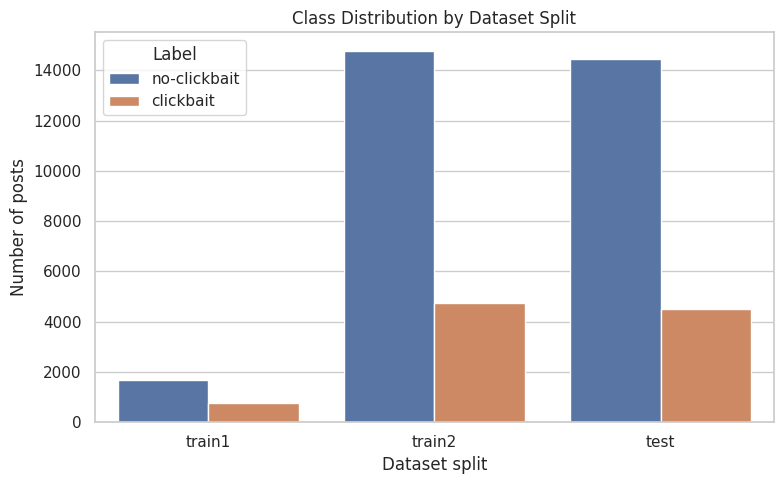

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=all_df, x="split", hue="label_name", order=SPLITS, hue_order=["no-clickbait", "clickbait"])
plt.title("Class Distribution by Dataset Split")
plt.xlabel("Dataset split")
plt.ylabel("Number of posts")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

The data is imbalanced, so later we focus on precision, recall, F1, and confusion matrices.

### 5.2 Text Length

We check post length because the input text is short and headline-like.

In [ ]:
length_summary = (
    all_df.groupby(["split", "label_name"])
    .agg(
        rows=("id", "count"),
        avg_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        min_words=("word_count", "min"),
        max_words=("word_count", "max"),
        avg_chars=("char_count", "mean"),
        median_chars=("char_count", "median"),
    )
    .reset_index()
)

for col in ["avg_words", "avg_chars"]:
    length_summary[col] = length_summary[col].round(2)

length_summary

,split,label_name,rows,avg_words,median_words,min_words,max_words,avg_chars,median_chars
0,test,clickbait,4515,9.97,10.0,0,24,57.45,59.0
1,test,no-clickbait,14464,11.98,12.0,0,26,74.18,74.0
2,train1,clickbait,762,11.96,12.0,3,26,71.80,70.0
3,train1,no-clickbait,1697,13.11,13.0,3,27,81.72,81.0
4,train2,clickbait,4761,10.11,10.0,0,25,58.63,60.0
5,train2,no-clickbait,14777,12.08,12.0,0,25,74.53,74.0


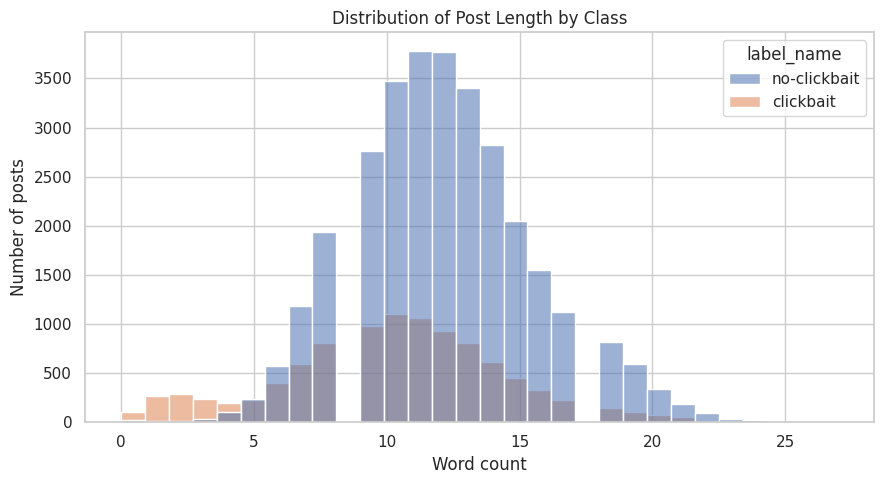

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(data=all_df, x="word_count", hue="label_name", bins=30, multiple="layer", alpha=0.55)
plt.title("Distribution of Post Length by Class")
plt.xlabel("Word count")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

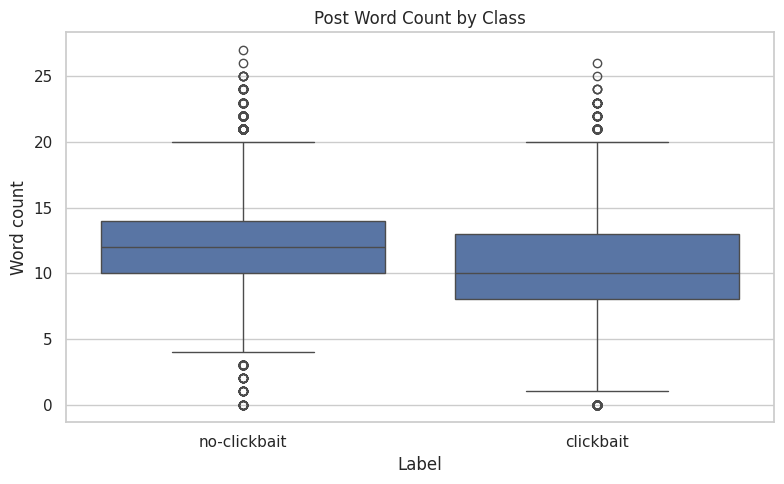

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=all_df, x="label_name", y="word_count", order=["no-clickbait", "clickbait"])
plt.title("Post Word Count by Class")
plt.xlabel("Label")
plt.ylabel("Word count")
plt.tight_layout()
plt.show()

### 5.3 Empty Text Records

Some records have empty postText. For those rows, we later use targetTitle as a fallback.

In [ ]:
empty_text_summary = (
    all_df[all_df["is_empty_text"]]
    .groupby(["split", "label_name"])
    .size()
    .reset_index(name="empty_rows")
)

empty_text_summary

,split,label_name,empty_rows
0,test,clickbait,57
1,test,no-clickbait,9
2,train2,clickbait,45
3,train2,no-clickbait,9


In [ ]:
all_df.loc[
    all_df["is_empty_text"],
    ["id", "split", "label_name", "text", "targetTitle"],
].head(10)

,id,split,label_name,text,targetTitle
2720,850909692721332224,train2,clickbait,,Jeff Sessions Slams Deal to Monitor Baltimore Police
2740,850321382714028035,train2,clickbait,,"Trump Ordered Syria Attack, then Ate Dinner with Chinese President"
2746,849966939820748800,train2,clickbait,,Donald Trump Ridicules ‘Horrible’ Susan Rice Interview with Andrea Mitchell
2764,849445548553842689,train2,clickbait,,"Illegal Immigration Fell 67 Percent under Trump, Says Fmr. Border Chief"
2767,849364334832750593,train2,clickbait,,Ann Coulter: Obama Should Testify Under Oath on Trump Campaign Surveillance
2805,848312710630694912,train2,clickbait,,Maher: It Looks Like Russia ‘Installed’ ‘Trump and His Crime Family’ ‘To Loot and Destroy America
4713,851069605351219200,train2,clickbait,,Fmr Obama Official Farkas: ‘Disturbing’ Rice Story Was Leaked and Distracted Us from Russia
4771,849679666571083777,train2,clickbait,,"MAFIA EU: Farage Blasts Bloc’s ‘Vindictive, Nasty’ Demands’"
4781,849259225398353920,train2,clickbait,,European Union Tells Hungary and Poland To Accept Mass Migration Or Leave
4823,848018381601214465,train2,clickbait,,Italy: Muslim Mother Shaves Head of Daughter Who Refused to Wear Veil


### 5.4 Human Judgment Distribution

These plots show how strongly annotators agreed on clickbait labels.

In [ ]:
judgment_summary = (
    all_df.groupby("label_name")
    .agg(
        rows=("id", "count"),
        avg_truth_mean=("truth_mean", "mean"),
        median_truth_mean=("truth_mean", "median"),
        avg_truth_median=("truth_median", "mean"),
        median_truth_median=("truth_median", "median"),
    )
    .reset_index()
)

for col in ["avg_truth_mean", "median_truth_mean", "avg_truth_median", "median_truth_median"]:
    judgment_summary[col] = judgment_summary[col].round(3)

judgment_summary

,label_name,rows,avg_truth_mean,median_truth_mean,avg_truth_median,median_truth_median
0,clickbait,10038,0.691,0.667,0.794,0.667
1,no-clickbait,30938,0.190,0.200,0.105,0.000


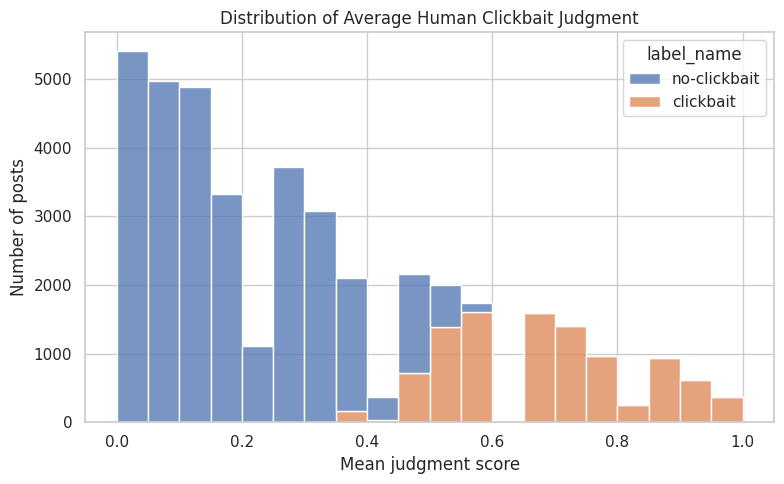

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=all_df, x="truth_mean", hue="label_name", bins=20, multiple="stack")
plt.title("Distribution of Average Human Clickbait Judgment")
plt.xlabel("Mean judgment score")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

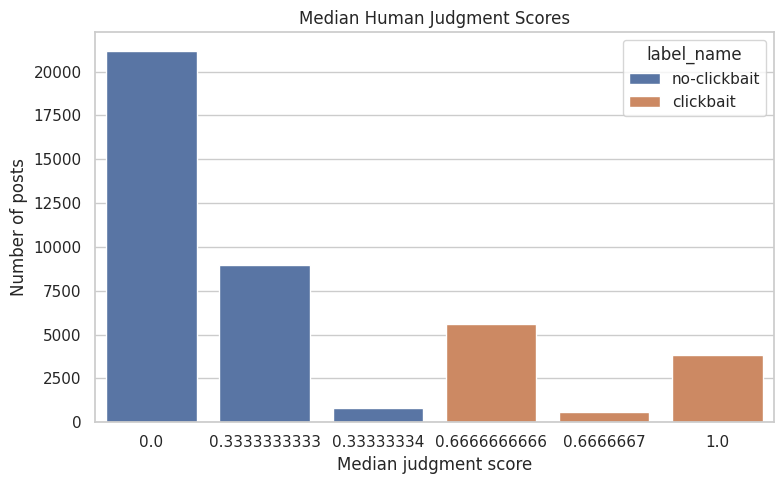

In [ ]:
median_counts = (
    all_df.groupby(["truth_median", "label_name"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(8, 5))
sns.barplot(data=median_counts, x="truth_median", y="count", hue="label_name")
plt.title("Median Human Judgment Scores")
plt.xlabel("Median judgment score")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

### 5.5 Example Posts

These examples help us see the writing style in each class.

In [ ]:
def show_examples(df, label, n=8):
    examples = (
        df[(df["label"] == label) & (~df["is_empty_text"])]
        .sample(n=min(n, ((df["label"] == label) & (~df["is_empty_text"])).sum()), random_state=RANDOM_STATE)
        [["split", "label_name", "truth_mean", "truth_median", "text"]]
        .reset_index(drop=True)
    )
    return examples

show_examples(all_df, label=1, n=8)

,split,label_name,truth_mean,truth_median,text
0,test,clickbait,0.466667,0.666667,Opinions: Trump’s shell game on Russia makes everything look suspicious
1,test,clickbait,0.600000,0.666667,Here's a breakdown of the best and riskiest moves for all 32 teams.
2,train2,clickbait,0.600000,0.666667,This heart-warming photo perfectly captures a non-verbal boy’s special bond with deaf dog
3,train2,clickbait,0.800000,0.666667,Teenagers who smoke cannabis damage their brains for LIFE
4,train2,clickbait,0.600000,0.666667,Netflix cheating is an actual thing and love is dead
5,train2,clickbait,0.866667,1.000000,#Poetry
6,train2,clickbait,0.733333,1.000000,He called the police after he dropped off the passengers to report a possible case of #childtrafficking
7,train2,clickbait,0.600000,0.666667,Nigeria's starving children who fled Boko Haram


In [ ]:
show_examples(all_df, label=0, n=8)

,split,label_name,truth_mean,truth_median,text
0,train2,no-clickbait,0.333333,0.333333,"""We wouldn't have come back without (Fisher-Davis)."" Vanderbilt player takes blame for loss, but team has his back:"
1,test,no-clickbait,0.066667,0.000000,Breaking News: The U.S. demands that China return an underwater drone seized by its warship in the South China Sea
2,test,no-clickbait,0.466667,0.333333,These are the key players in the ongoing Trump-Russia saga
3,test,no-clickbait,0.133333,0.000000,Magic Johnson reportedly wants Kobe Bryant to return to Lakers in player relations role
4,train2,no-clickbait,0.400000,0.333333,Inside XXXTentacion's complicated legal situation
5,test,no-clickbait,0.066667,0.000000,Rogue One VFX head defends recreating Peter Cushing
6,train2,no-clickbait,0.066667,0.000000,White House tells agencies to come up with a plan to shrink their workforces
7,test,no-clickbait,0.066667,0.000000,The US and China are weighing responses to North Korea's failed missile launch


### 5.6 Frequent Terms by Class

This simple term check helps us see visible word patterns before using neural networks.

In [ ]:
def top_terms_by_class(df, label, n_terms=20):
    texts = df[(df["label"] == label) & (~df["is_empty_text"])]["text"]

    vectorizer = CountVectorizer(
        lowercase=True,
        stop_words=list(ENGLISH_STOP_WORDS),
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b",
        min_df=5,
    )
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()

    return (
        pd.DataFrame({"term": terms, "count": counts})
        .sort_values("count", ascending=False)
        .head(n_terms)
        .reset_index(drop=True)
    )

clickbait_terms = top_terms_by_class(all_df, label=1, n_terms=20)
non_clickbait_terms = top_terms_by_class(all_df, label=0, n_terms=20)

clickbait_terms.head(10)

,term,count
0,new,390
1,trump,379
2,here's,331
3,best,315
4,people,312
5,know,295
6,just,270
7,things,253
8,make,238
9,year,226


In [ ]:
non_clickbait_terms.head(10)

,term,count
0,trump,3225
1,new,1806
2,says,1368
3,president,887
4,trump's,819
5,year,797
6,donald,792
7,people,646
8,house,624
9,police,605


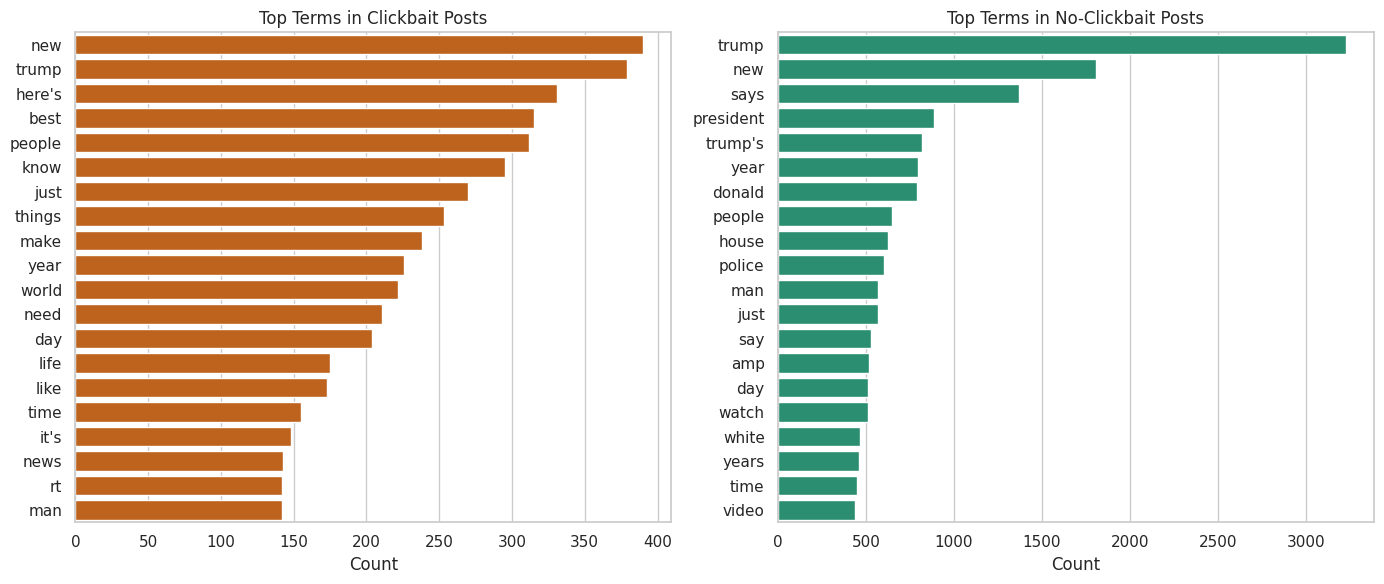

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

sns.barplot(data=clickbait_terms, y="term", x="count", ax=axes[0], color="#d95f02")
axes[0].set_title("Top Terms in Clickbait Posts")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.barplot(data=non_clickbait_terms, y="term", x="count", ax=axes[1], color="#1b9e77")
axes[1].set_title("Top Terms in No-Clickbait Posts")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The EDA section suggests several points for the modeling stage:

1. The dataset files can be reliably matched using id.
2. A binary clickbait label can be constructed from the median of truthJudgments, and this label matches the official truthClass field.
3. The data is moderately imbalanced, with no-clickbait posts representing the larger class.
4. The input text is short, which makes this a headline-style text classification problem.
5. A small number of records have empty postText, which should be handled before training.
6. Because of class imbalance, the modeling section should report F1 score, precision, recall, and confusion matrices in addition to accuracy.

## 6. Text Preprocessing

We combine train1 and train2, split out a validation set, and keep test for final evaluation. If postText is empty, we use targetTitle as a fallback.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

model_df = all_df.copy()
model_df["model_text"] = model_df["text"]
empty_mask = model_df["model_text"].eq("")
model_df.loc[empty_mask, "model_text"] = model_df.loc[empty_mask, "targetTitle"].fillna("").str.strip()
model_df["model_text_is_fallback"] = empty_mask.astype(int)

model_df = model_df[model_df["model_text"].str.len() > 0].reset_index(drop=True)

train_dev_df = model_df[model_df["split"].isin(["train1", "train2"])].reset_index(drop=True)
final_test_df = model_df[model_df["split"].eq("test")].reset_index(drop=True)

print(f"Development rows from train1 + train2: {len(train_dev_df):,}")
print(f"Final test rows: {len(final_test_df):,}")
print(f"Rows using targetTitle fallback: {model_df['model_text_is_fallback'].sum():,}")

Development rows from train1 + train2: 21,997
Final test rows: 18,979
Rows using targetTitle fallback: 120


In [ ]:
train_split_df, val_split_df = train_test_split(
    train_dev_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_dev_df["label"],
)

X_train = train_split_df["model_text"].astype(str).to_numpy()
y_train = train_split_df["label"].astype("int32").to_numpy()

X_val = val_split_df["model_text"].astype(str).to_numpy()
y_val = val_split_df["label"].astype("int32").to_numpy()

X_test = final_test_df["model_text"].astype(str).to_numpy()
y_test = final_test_df["label"].astype("int32").to_numpy()

split_model_summary = pd.DataFrame({
    "dataset": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "clickbait_rows": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "clickbait_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
})
split_model_summary["clickbait_rate"] = split_model_summary["clickbait_rate"].map(lambda x: f"{x:.2%}")
split_model_summary

,dataset,rows,clickbait_rows,clickbait_rate
0,train,17597,4418,25.11%
1,validation,4400,1105,25.11%
2,test,18979,4515,23.79%


We use class weights because clickbait is the smaller class.

In [ ]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
class_weight

{0: 0.6676151453069277, 1: 1.9915119963784518}

## 7. Baseline Model

The baseline model is as below:

TextVectorization-Embedding-GlobalAveragePooling1D-Dense-Sigmoid

Loss function: binary_crossentropy

### 7.1 Keras Setup


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(RANDOM_STATE)

In [ ]:
MAX_TOKENS = 12000
SEQUENCE_LENGTH = 32
EMBEDDING_DIM = 64
BATCH_SIZE = 128
EPOCHS = 10

text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
)
text_vectorizer.adapt(X_train)

vocab = text_vectorizer.get_vocabulary()
print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 12,000


In [ ]:
sample_texts = X_train[:3]
sample_tokens = text_vectorizer(sample_texts).numpy()

pd.DataFrame({
    "text": sample_texts,
    "vectorized_tokens": sample_tokens.tolist(),
})

,text,vectorized_tokens
0,This Topshop graphic tee has a major typo,"[17, 8878, 3253, 6905, 23, 5, 342, 8809, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,17 times Americans went too hard on Valentine’s Day,"[527, 231, 296, 417, 268, 596, 10, 4202, 63, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,Now here's a lesson on spotting fake news (courtesy of Facebook),"[65, 86, 5, 3945, 10, 1, 377, 101, 3287, 6, 272, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


### 7.2 Build the Baseline Model

This model uses binary_crossentropy because the task is binary classification. We track accuracy, AUC, precision, and recall for interpretation.

In [ ]:
def build_baseline_model():
    inputs = keras.Input(shape=(1,), dtype=tf.string, name="post_text")
    x = text_vectorizer(inputs)
    x = layers.Embedding(
        input_dim=len(vocab),
        output_dim=EMBEDDING_DIM,
        mask_zero=False,
        name="token_embedding",
    )(x)
    x = layers.GlobalAveragePooling1D(name="average_embedding_pooling")(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="clickbait_probability")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="baseline_embedding_classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "baseline_embedding_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ post_text (InputLayer)          │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 32, 64)         │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_embedding_pooling       │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clickbait_probability (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,225 (2.95 MB)

 Trainable params: 772,225 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

### 7.3 Train the Baseline Model

We use early stopping to reduce overfitting, because headline texts are short and the model may quickly memorize frequent phrases.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
)

terminate_on_nan = keras.callbacks.TerminateOnNaN()

history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr, terminate_on_nan],
    verbose=1,
)

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5565 - auc: 0.6790 - loss: 0.6645 - precision: 0.3282 - recall: 0.7318 - val_accuracy: 0.6845 - val_auc: 0.7971 - val_loss: 0.6058 - val_precision: 0.4295 - val_recall: 0.7801 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7615 - auc: 0.8383 - loss: 0.5083 - precision: 0.5170 - recall: 0.7603 - val_accuracy: 0.7632 - val_auc: 0.8439 - val_loss: 0.4996 - val_precision: 0.5191 - val_recall: 0.7738 - learning_rate: 0.0010
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8145 - auc: 0.8905 - loss: 0.4201 - precision: 0.5941 - recall: 0.8248 - val_accuracy: 0.7843 - val_auc: 0.8521 - val_loss: 0.4671 - val_precision: 0.5515 - val_recall: 0.7557 - learning_rate: 0.0010
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8451 - auc: 0.9193 - loss: 0.3612 - precision: 0.6430 - recall: 0.8617 - val_accuracy: 0.7855 - val_auc: 0.8497 - val_loss: 0.4723 -

### 7.4 Training Curves

The plots below compare training and validation performance across epochs.

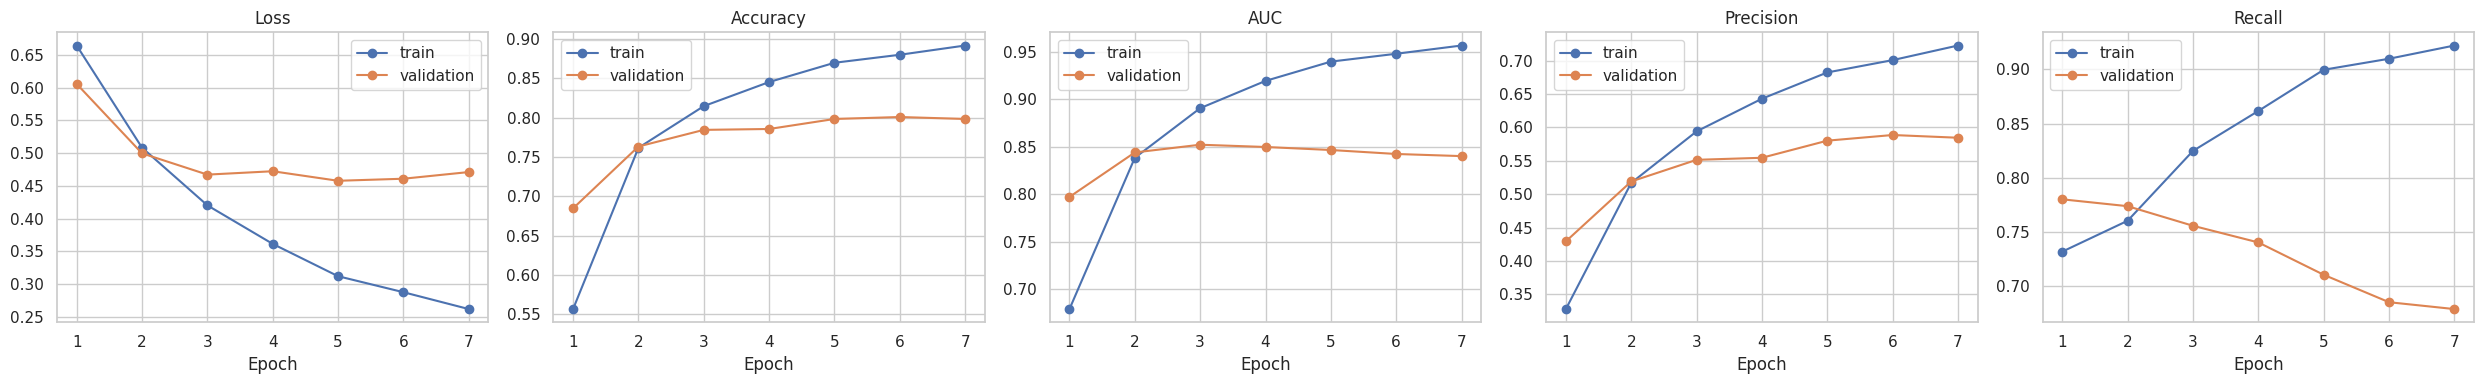

In [ ]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)
    metric_pairs = [
        ("loss", "val_loss", "Loss"),
        ("accuracy", "val_accuracy", "Accuracy"),
        ("auc", "val_auc", "AUC"),
        ("precision", "val_precision", "Precision"),
        ("recall", "val_recall", "Recall"),
    ]
    available = [pair for pair in metric_pairs if pair[0] in history_df.columns and pair[1] in history_df.columns]

    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
    if len(available) == 1:
        axes = [axes]

    for ax, (train_metric, val_metric, title) in zip(axes, available):
        ax.plot(history_df.index + 1, history_df[train_metric], marker="o", label="train")
        ax.plot(history_df.index + 1, history_df[val_metric], marker="o", label="validation")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    plt.tight_layout()
    plt.show()
    return history_df

baseline_history_df = plot_training_history(history)

### 7.5 Baseline Evaluation

We evaluate the baseline on the held-out test set.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_test_metrics = baseline_model.evaluate(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0,
    return_dict=True,
)

pd.DataFrame(
    baseline_test_metrics.items(),
    columns=["metric", "value"],
).sort_values("metric").reset_index(drop=True)

,metric,value
0,accuracy,0.806418
1,auc,0.869375
2,loss,0.435127
3,precision,0.568968
4,recall,0.768328


In [ ]:
y_test_prob = baseline_model.predict(X_test, batch_size=BATCH_SIZE).ravel()
y_test_pred = (y_test_prob >= 0.5).astype(int)

baseline_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_prob),
    ],
})
baseline_summary["value"] = baseline_summary["value"].round(4)
baseline_summary

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,metric,value
0,accuracy,0.8064
1,precision,0.5690
2,recall,0.7683
3,f1,0.6538
4,roc_auc,0.8693


In [ ]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["no-clickbait", "clickbait"],
    zero_division=0,
))

              precision    recall  f1-score   support

no-clickbait       0.92      0.82      0.87     14464
   clickbait       0.57      0.77      0.65      4515

    accuracy                           0.81     18979
   macro avg       0.74      0.79      0.76     18979
weighted avg       0.84      0.81      0.82     18979



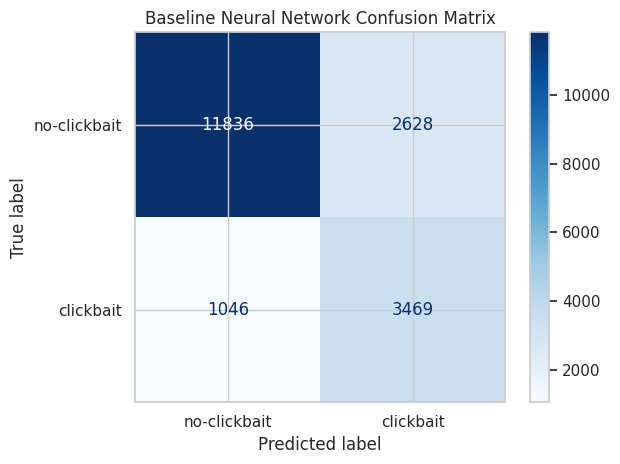

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no-clickbait", "clickbait"])

disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

### 7.6 Error Analysis

We look at false positives and false negatives from the baseline model.

In [ ]:
error_analysis_df = final_test_df.copy()
error_analysis_df["predicted_probability"] = y_test_prob
error_analysis_df["predicted_label"] = y_test_pred
error_analysis_df["predicted_class"] = np.where(error_analysis_df["predicted_label"].eq(1), "clickbait", "no-clickbait")
error_analysis_df["actual_class"] = np.where(error_analysis_df["label"].eq(1), "clickbait", "no-clickbait")
error_analysis_df["correct"] = error_analysis_df["predicted_label"].eq(error_analysis_df["label"])

false_positives = (
    error_analysis_df[(error_analysis_df["label"] == 0) & (error_analysis_df["predicted_label"] == 1)]
    .sort_values("predicted_probability", ascending=False)
)

false_negatives = (
    error_analysis_df[(error_analysis_df["label"] == 1) & (error_analysis_df["predicted_label"] == 0)]
    .sort_values("predicted_probability", ascending=True)
)

print(f"False positives: {len(false_positives):,}")
print(f"False negatives: {len(false_negatives):,}")

False positives: 2,628
False negatives: 1,046


In [ ]:
false_positives[["actual_class", "predicted_class", "predicted_probability", "truth_mean", "model_text"]].head(10)

,actual_class,predicted_class,predicted_probability,truth_mean,model_text
11576,no-clickbait,clickbait,0.987577,0.200000,Here's how Apple will handle things if your MacBook is damaged in your checked luggage
7620,no-clickbait,clickbait,0.985423,0.533333,How well do you remember Love Actually? Take the quiz and find out
9051,no-clickbait,clickbait,0.982413,0.400000,Literally just 18 really cute and wholesome Tumblr posts
1122,no-clickbait,clickbait,0.981100,0.400000,Instant Pots are the kitchen gadget of the moment. Here’s what it does (and doesn’t do) well.
10922,no-clickbait,clickbait,0.980291,0.600000,The 50 most hilarious tweets from parents this year
1742,no-clickbait,clickbait,0.980100,0.466667,Here's how much legroom you get on America's airlines
5361,no-clickbait,clickbait,0.979446,0.266667,People dumping bikes on the street is why we can’t have nice things
5363,no-clickbait,clickbait,0.979280,0.466667,SunTrustVoice: 5 things to know about getting an accurate business valuation
15359,no-clickbait,clickbait,0.978661,0.333333,These are the stories that made headlines today. #News
6503,no-clickbait,clickbait,0.978291,0.400000,#ICYMI: What's all the fuss about #18C and why does it matter?


In [ ]:
false_negatives[["actual_class", "predicted_class", "predicted_probability", "truth_mean", "model_text"]].head(10)

,actual_class,predicted_class,predicted_probability,truth_mean,model_text
2255,clickbait,no-clickbait,0.002196,0.733333,PolitiFact Pulls 2014 ‘Mostly True’ Rating of John Kerry’s Claim of Eliminating Syrian Chemical Weapons
1276,clickbait,no-clickbait,0.002408,0.600000,Economic Scene: Mexico’s Potential Weapons if Trump Declares War on Nafta
15316,clickbait,no-clickbait,0.002495,0.800000,Swedish Police Chief Shut Down By Interior Minister After Call to Deport Terror Suspects
2807,clickbait,no-clickbait,0.002693,0.800000,🔥 🔥 Send in a BERN UNIT because Bernie Sanders just poured hotfire BERN SAUCE all over Trump with epic BERN 🔥 🔥
15371,clickbait,no-clickbait,0.003352,0.666667,"Capitol Hill Source: Intel Chair Nunes Temporarily Stepped Down from Russia Probe to Keep Focus on Russia, Unmasking Scandal"
8247,clickbait,no-clickbait,0.003505,1.000000,Trump: It Is In ‘Vital National Security Interest of the US’ to Prevent the Use of Chemical Weapons
13897,clickbait,no-clickbait,0.005219,0.666667,"He allegedly duped a person, promising high returns on investments of several crores in his housing project in Noida"
12088,clickbait,no-clickbait,0.005968,0.400000,Federal Government moves to change Native Title Act after shock court ruling #auspol
4250,clickbait,no-clickbait,0.006810,0.800000,Utah Lawmakers Pass Measure Calling on Congress to Abolish U.S. Education Department
16483,clickbait,no-clickbait,0.007143,0.533333,See inside the $5.5 million mansion Ivanka Trump and Jared Kushner will reportedly move into


This baseline neural network provides the first benchmark for clickbait detection using only text from the online post. It uses learned word embeddings and a simple pooling architecture, which makes it a useful starting point for comparison.

## 8. Improved Model: Bidirectional LSTM

The baseline averages word embeddings, and it loses much of the word-order information in the headline. Clickbait often depends on phrasing, suspense, or incomplete information, such as "you won't believe," "this is why," or question-style constructions. These patterns are partly sequential.
To add more modeling depth and capture sequence patterns, we train a Bidirectional LSTM model. We keep the same train/validation/test split and the same TextVectorization layer used in the baseline model.

Main architecture:

**TextVectorization-Embedding-Bidirectional LSTM-GlobalMaxPooling1D-Dense-Sigmoid**

Loss function: binary_crossentropy.

### 8.1 Build the Improved Model

This model is deeper than the baseline and can use word order information. Because the dataset is moderately imbalanced, we continue to use class weights during training.

In [ ]:
def build_bilstm_model():
    inputs = keras.Input(shape=(1,), dtype=tf.string, name="post_text")
    x = text_vectorizer(inputs)

    x = layers.Embedding(
        input_dim=len(vocab),
        output_dim=EMBEDDING_DIM,
        mask_zero=False,
        name="token_embedding",
    )(x)
    x = layers.SpatialDropout1D(0.20)(x)
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.20, recurrent_dropout=0.0),
        name="bidirectional_lstm",
    )(x)
    x = layers.GlobalMaxPooling1D(name="global_max_pooling")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="clickbait_probability")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="improved_bilstm_classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=7.5e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

bilstm_model = build_bilstm_model()
bilstm_model.summary()

Model: "improved_bilstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ post_text (InputLayer)          │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 32, 64)         │       768,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 32, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 32, 128)        │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling              │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clickbait_probability (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 842,881 (3.22 MB)

 Trainable params: 842,625 (3.21 MB)

 Non-trainable params: 256 (1.00 KB)

### 8.2 Train the Improved Model

We use early stopping again, but allow a slightly longer patience because sequence models may need more epochs to converge than the baseline pooling model.

In [ ]:
bilstm_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

bilstm_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
)

bilstm_terminate_on_nan = keras.callbacks.TerminateOnNaN()

bilstm_history = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[bilstm_early_stopping, bilstm_reduce_lr, bilstm_terminate_on_nan],
    verbose=1,
)

Epoch 1/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.6910 - auc: 0.7703 - loss: 0.5698 - precision: 0.4289 - recall: 0.6960 - val_accuracy: 0.7500 - val_auc: 0.8484 - val_loss: 0.5891 - val_precision: 0.8571 - val_recall: 0.0054 - learning_rate: 7.5000e-04
Epoch 2/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.8152 - auc: 0.9012 - loss: 0.3988 - precision: 0.5932 - recall: 0.8402 - val_accuracy: 0.7668 - val_auc: 0.8424 - val_loss: 0.4827 - val_precision: 0.8762 - val_recall: 0.0833 - learning_rate: 7.5000e-04
Epoch 3/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.8581 - auc: 0.9430 - loss: 0.3026 - precision: 0.6598 - recall: 0.8977 - val_accuracy: 0.8023 - val_auc: 0.8258 - val_loss: 0.4534 - val_precision: 0.7887 - val_recall: 0.2905 - learning_rate: 7.5000e-04
Epoch 4/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.8948 - auc: 0.9649 - loss: 0.2307 - precision: 0.7232 - recall: 0.9414 - val_accuracy: 0.8077 - val_auc: 0.8133 

In [ ]:
bilstm_history_df = plot_training_history(bilstm_history)

### 8.3 Threshold Tuning

The default classification threshold is 0.50: if the predicted clickbait probability is at least 0.50, the model predicts clickbait. However, in a real-world setting, the best threshold depends on the cost of different mistakes. We tune the threshold on the validation set by maximizing F1.

In [ ]:
from sklearn.metrics import precision_recall_curve

val_prob_bilstm = bilstm_model.predict(X_val, batch_size=BATCH_SIZE).ravel()
precision_vals, recall_vals, threshold_vals = precision_recall_curve(y_val, val_prob_bilstm)

threshold_eval = pd.DataFrame({
    "threshold": threshold_vals,
    "precision": precision_vals[:-1],
    "recall": recall_vals[:-1],
})
threshold_eval["f1"] = (
    2 * threshold_eval["precision"] * threshold_eval["recall"] /
    (threshold_eval["precision"] + threshold_eval["recall"] + 1e-8)
)

best_threshold_row = threshold_eval.sort_values("f1", ascending=False).iloc[0]
best_threshold = float(best_threshold_row["threshold"])
best_threshold_row.to_frame().T

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_eval["threshold"], threshold_eval["precision"], label="Precision")
plt.plot(threshold_eval["threshold"], threshold_eval["recall"], label="Recall")
plt.plot(threshold_eval["threshold"], threshold_eval["f1"], label="F1")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Best F1 threshold = {best_threshold:.2f}")
plt.title("Validation Threshold Tuning for Improved Model")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

### 8.4 Improved Model Evaluation

We test the tuned BiLSTM on the held-out test set.

In [ ]:
# Use return_dict=True for compatibility with current Keras versions.
bilstm_test_metrics = bilstm_model.evaluate(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0,
    return_dict=True,
)

pd.DataFrame(
    bilstm_test_metrics.items(),
    columns=["metric", "value"],
).sort_values("metric").reset_index(drop=True)

In [ ]:
y_test_prob_bilstm = bilstm_model.predict(X_test, batch_size=BATCH_SIZE).ravel()
y_test_pred_bilstm_default = (y_test_prob_bilstm >= 0.50).astype(int)
y_test_pred_bilstm_tuned = (y_test_prob_bilstm >= best_threshold).astype(int)

bilstm_comparison = pd.DataFrame({
    "model": ["BiLSTM default threshold", "BiLSTM tuned threshold"],
    "threshold": [0.50, best_threshold],
    "accuracy": [
        accuracy_score(y_test, y_test_pred_bilstm_default),
        accuracy_score(y_test, y_test_pred_bilstm_tuned),
    ],
    "precision": [
        precision_score(y_test, y_test_pred_bilstm_default, zero_division=0),
        precision_score(y_test, y_test_pred_bilstm_tuned, zero_division=0),
    ],
    "recall": [
        recall_score(y_test, y_test_pred_bilstm_default, zero_division=0),
        recall_score(y_test, y_test_pred_bilstm_tuned, zero_division=0),
    ],
    "f1": [
        f1_score(y_test, y_test_pred_bilstm_default, zero_division=0),
        f1_score(y_test, y_test_pred_bilstm_tuned, zero_division=0),
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_test_prob_bilstm),
        roc_auc_score(y_test, y_test_prob_bilstm),
    ],
})
for col in ["threshold", "accuracy", "precision", "recall", "f1", "roc_auc"]:
    bilstm_comparison[col] = bilstm_comparison[col].round(4)
bilstm_comparison

149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step


,model,threshold,accuracy,precision,recall,f1,roc_auc
0,BiLSTM default threshold,0.5000,0.8197,0.7973,0.3249,0.4617,0.857
1,BiLSTM tuned threshold,0.2198,0.8211,0.6144,0.6656,0.6390,0.857


In [ ]:
print("BiLSTM with tuned threshold")
print(classification_report(
    y_test,
    y_test_pred_bilstm_tuned,
    target_names=["no-clickbait", "clickbait"],
    zero_division=0,
))

BiLSTM with tuned threshold
              precision    recall  f1-score   support

no-clickbait       0.89      0.87      0.88     14464
   clickbait       0.61      0.67      0.64      4515

    accuracy                           0.82     18979
   macro avg       0.75      0.77      0.76     18979
weighted avg       0.83      0.82      0.82     18979



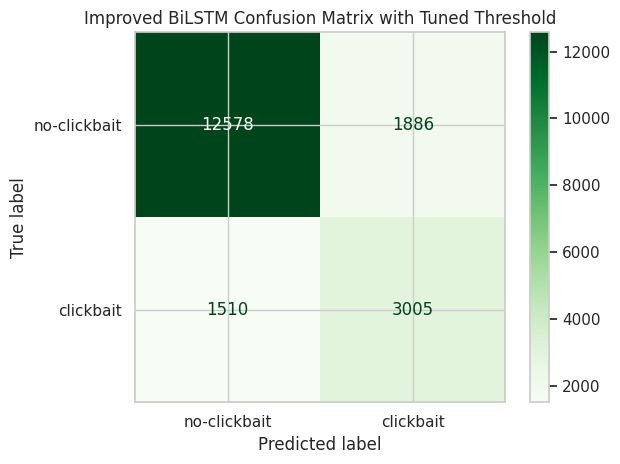

In [ ]:
cm_bilstm = confusion_matrix(y_test, y_test_pred_bilstm_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bilstm, display_labels=["no-clickbait", "clickbait"])

disp.plot(cmap="Greens", values_format="d")
plt.title("Improved BiLSTM Confusion Matrix with Tuned Threshold")
plt.tight_layout()
plt.show()

### 8.5 Improved Model Error Analysis

We inspect the strongest mistakes from the improved model.

In [ ]:
bilstm_error_df = final_test_df.copy()
bilstm_error_df["predicted_probability"] = y_test_prob_bilstm
bilstm_error_df["predicted_label"] = y_test_pred_bilstm_tuned
bilstm_error_df["predicted_class"] = np.where(bilstm_error_df["predicted_label"].eq(1), "clickbait", "no-clickbait")
bilstm_error_df["actual_class"] = np.where(bilstm_error_df["label"].eq(1), "clickbait", "no-clickbait")
bilstm_error_df["correct"] = bilstm_error_df["predicted_label"].eq(bilstm_error_df["label"])

bilstm_false_positives = (
    bilstm_error_df[(bilstm_error_df["label"] == 0) & (bilstm_error_df["predicted_label"] == 1)]
    .sort_values("predicted_probability", ascending=False)
)

bilstm_false_negatives = (
    bilstm_error_df[(bilstm_error_df["label"] == 1) & (bilstm_error_df["predicted_label"] == 0)]
    .sort_values("predicted_probability", ascending=True)
)

print(f"BiLSTM false positives: {len(bilstm_false_positives):,}")
print(f"BiLSTM false negatives: {len(bilstm_false_negatives):,}")

BiLSTM false positives: 1,886
BiLSTM false negatives: 1,510


In [ ]:
bilstm_false_positives[["actual_class", "predicted_class", "predicted_probability", "truth_mean", "model_text"]].head(10)

,actual_class,predicted_class,predicted_probability,truth_mean,model_text
9051,no-clickbait,clickbait,0.779384,0.400000,Literally just 18 really cute and wholesome Tumblr posts
12209,no-clickbait,clickbait,0.778021,0.600000,10 shocking confessions from nannies
17551,no-clickbait,clickbait,0.766415,0.533333,How to get divorced
1742,no-clickbait,clickbait,0.755945,0.466667,Here's how much legroom you get on America's airlines
17480,no-clickbait,clickbait,0.752419,0.466667,This really happened last night #MarchMadness
3080,no-clickbait,clickbait,0.740951,0.266667,What's your answer to @KatrinaPierson's question?
11656,no-clickbait,clickbait,0.740501,0.466667,This woman quit a successful Wall Street career to open a bakery. Read her story:
12203,no-clickbait,clickbait,0.739514,0.200000,Why you should want the Super Bowl to be a blowout
15359,no-clickbait,clickbait,0.739374,0.333333,These are the stories that made headlines today. #News
17602,no-clickbait,clickbait,0.736954,0.400000,Can YOU find the hidden raven?


In [ ]:
bilstm_false_negatives[["actual_class", "predicted_class", "predicted_probability", "truth_mean", "model_text"]].head(10)

,actual_class,predicted_class,predicted_probability,truth_mean,model_text
1276,clickbait,no-clickbait,0.003040,0.600000,Economic Scene: Mexico’s Potential Weapons if Trump Declares War on Nafta
280,clickbait,no-clickbait,0.006480,0.466667,"""Boss Baby"" author says comparing trump to infant character makes total sense"
15316,clickbait,no-clickbait,0.006684,0.800000,Swedish Police Chief Shut Down By Interior Minister After Call to Deport Terror Suspects
15212,clickbait,no-clickbait,0.007246,0.466667,Man's attempt to down fiery shot ends in predictable disaster
15371,clickbait,no-clickbait,0.007961,0.666667,"Capitol Hill Source: Intel Chair Nunes Temporarily Stepped Down from Russia Probe to Keep Focus on Russia, Unmasking Scandal"
6351,clickbait,no-clickbait,0.008136,0.800000,Gorka: Story That Secretary of State Tillerson Refuses Eye Contact with Diplomats Is ‘Fake News’
2255,clickbait,no-clickbait,0.008656,0.733333,PolitiFact Pulls 2014 ‘Mostly True’ Rating of John Kerry’s Claim of Eliminating Syrian Chemical Weapons
11238,clickbait,no-clickbait,0.008782,0.733333,How east Africa's first state pension is changing lives – in pictures
6364,clickbait,no-clickbait,0.008857,0.466667,Mexico City metro installs 'penis seat' to stop sexual harassment of women #FOXNewsWorld
4250,clickbait,no-clickbait,0.008940,0.800000,Utah Lawmakers Pass Measure Calling on Congress to Abolish U.S. Education Department


## 9. Pretrained Model: Universal Sentence Encoder

We also test a pretrained model. Instead of learning text features from scratch, this model starts from the Universal Sentence Encoder (USE).

Why use a pretrained model?
- it already has strong semantic information
- it often works well on short text
- it gives a meaningful contrast with models trained from scratch

Architecture used here:

**input-pretrained USE embedding layer-dense layer-sigmoid output**

Loss function: binary_crossentropy.

### 9.1 Build and Train the Pretrained Model

We freeze the pretrained text encoder and train a small classifier on top of it.

In [ ]:
import tensorflow_hub as hub

USE_URL = "https://tfhub.dev/google/universal-sentence-encoder/4"
use_encoder = hub.load(USE_URL)

class USELayer(layers.Layer):
    def __init__(self, encoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.trainable = False

    def call(self, inputs):
        return self.encoder(inputs)


def build_use_model():
    inputs = keras.Input(shape=(), dtype=tf.string, name="post_text")
    x = USELayer(use_encoder, name="use_encoder")(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="clickbait_probability")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="pretrained_use_classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model

use_model = build_use_model()
use_model.summary()

Epoch 1/6
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.7510 - auc: 0.8105 - loss: 0.5566 - precision: 0.5028 - recall: 0.7395 - val_accuracy: 0.7814 - val_auc: 0.8565 - val_loss: 0.5023 - val_precision: 0.5442 - val_recall: 0.7973
Epoch 2/6
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7958 - auc: 0.8568 - loss: 0.4732 - precision: 0.5692 - recall: 0.7671 - val_accuracy: 0.7877 - val_auc: 0.8608 - val_loss: 0.4870 - val_precision: 0.5542 - val_recall: 0.7910
Epoch 3/6
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7986 - auc: 0.8621 - loss: 0.4644 - precision: 0.5740 - recall: 0.7669 - val_accuracy: 0.7855 - val_auc: 0.8616 - val_loss: 0.4848 - val_precision: 0.5507 - val_recall: 0.7910
Epoch 4/6
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7995 - auc: 0.8671 - loss: 0.4569 - precision: 0.5748 - recall: 0.7734 - val_accuracy: 0.7841 - val_auc: 0.8625 - val_loss: 0.4824 - val_precision: 0.5488 - val_recall: 0.7891
Epoch 5/6
138/138 ━━━━━━━━━━━━━━

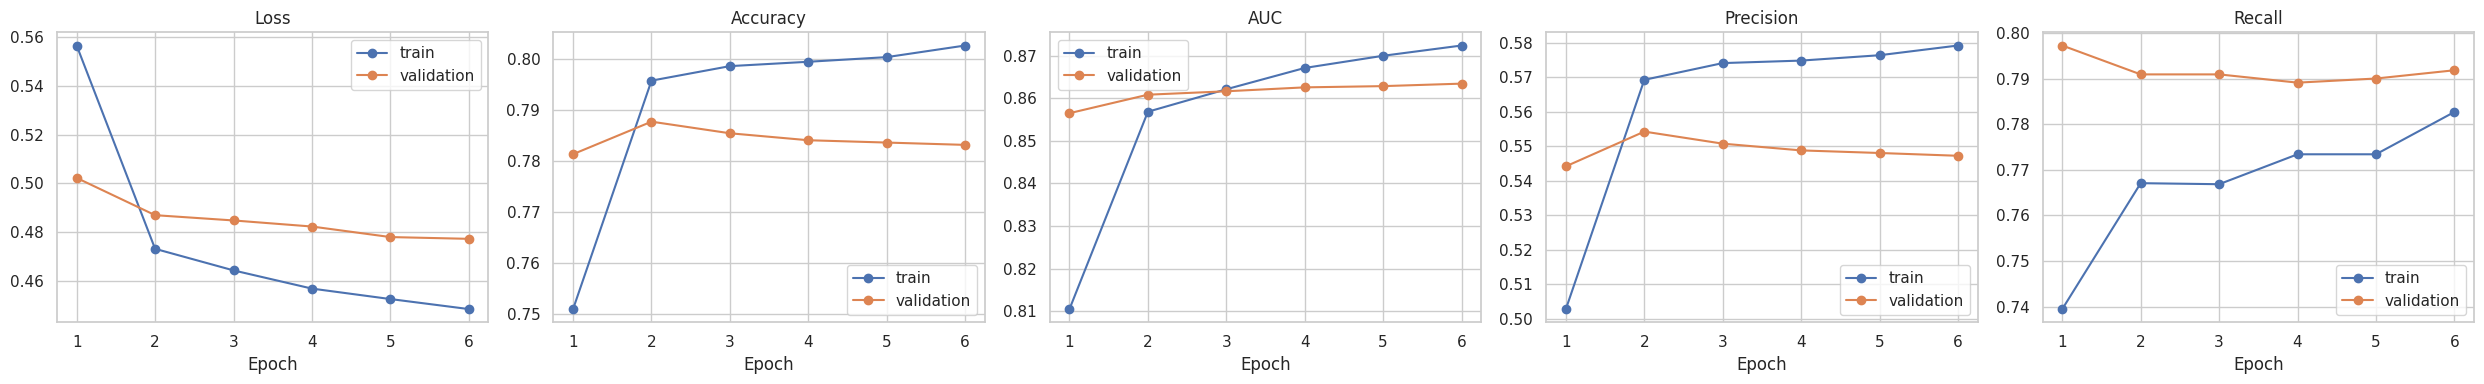

In [ ]:
use_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

use_history = use_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[use_early_stopping],
    verbose=1,
)

use_history_df = plot_training_history(use_history)

### 9.2 Evaluate the Pretrained Model

We use the same test set so the comparison stays fair.

In [ ]:
use_test_prob = use_model.predict(X_test, batch_size=BATCH_SIZE).ravel()
use_test_pred = (use_test_prob >= 0.50).astype(int)

use_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [
        accuracy_score(y_test, use_test_pred),
        precision_score(y_test, use_test_pred, zero_division=0),
        recall_score(y_test, use_test_pred, zero_division=0),
        f1_score(y_test, use_test_pred, zero_division=0),
        roc_auc_score(y_test, use_test_prob),
    ],
})
use_summary["value"] = use_summary["value"].round(4)
use_summary

149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step


,metric,value
0,accuracy,0.7892
1,precision,0.5370
2,recall,0.8277
3,f1,0.6514
4,roc_auc,0.8844


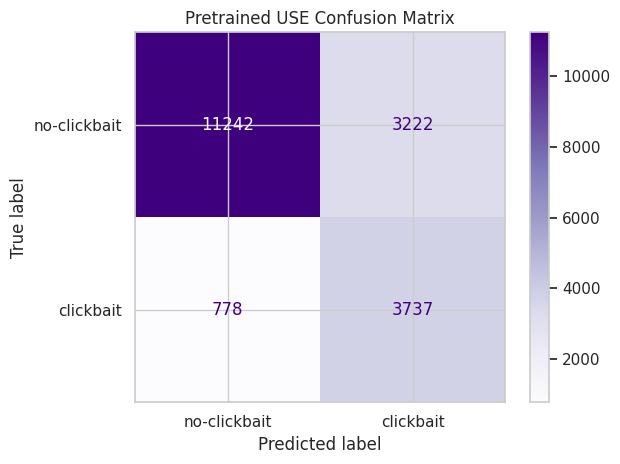

In [ ]:
cm_use = confusion_matrix(y_test, use_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_use, display_labels=["no-clickbait", "clickbait"]).plot(cmap="Purples", values_format="d")
plt.title("Pretrained USE Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Benchmark Models

We compare the neural models with two simple benchmarks:

1. **Majority class**: always predict the dominant class.
2. **Random guess**: use the clickbait rate in the training data.

These benchmarks show whether the neural models are better than simple rules.

In [ ]:
majority_label = int(pd.Series(y_train).mode()[0])
clickbait_rate_train = float(np.mean(y_train))

majority_pred = np.full_like(y_test, fill_value=majority_label)
random_prob = np.full(shape=len(y_test), fill_value=clickbait_rate_train)
random_pred = (random_prob >= 0.5).astype(int)

benchmark_comparison = pd.DataFrame([
    {
        "model": "Majority class baseline",
        "threshold": np.nan,
        "accuracy": round(accuracy_score(y_test, majority_pred), 4),
        "precision": round(precision_score(y_test, majority_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, majority_pred, zero_division=0), 4),
        "f1": round(f1_score(y_test, majority_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, random_prob), 4),
    },
    {
        "model": "Random guess baseline",
        "threshold": 0.50,
        "accuracy": round(accuracy_score(y_test, random_pred), 4),
        "precision": round(precision_score(y_test, random_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, random_pred, zero_division=0), 4),
        "f1": round(f1_score(y_test, random_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, random_prob), 4),
    },
])
benchmark_comparison

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Majority class baseline,NaN,0.7621,0.0,0.0,0.0,0.5
1,Random guess baseline,0.5,0.7621,0.0,0.0,0.0,0.5


## 11. Final Model Comparison

This table compares:
- majority class benchmark
- random guess benchmark
- baseline embedding model
- BiLSTM model
- pretrained USE model

For the presentation, focus on F1, precision, recall, and the confusion matrices.

In [ ]:
baseline_comparison = (
    baseline_summary.assign(model="Baseline embedding model", threshold=0.50)
    .pivot_table(index=["model", "threshold"], columns="metric", values="value")
    .reset_index()
)

use_comparison = (
    use_summary.assign(model="Pretrained USE model", threshold=0.50)
    .pivot_table(index=["model", "threshold"], columns="metric", values="value")
    .reset_index()
)

bilstm_best = bilstm_comparison[bilstm_comparison["model"].eq("BiLSTM tuned threshold")].copy()

model_comparison = pd.concat(
    [benchmark_comparison, baseline_comparison, bilstm_best, use_comparison],
    ignore_index=True,
    sort=False,
)

comparison_columns = ["model", "threshold", "accuracy", "precision", "recall", "f1", "roc_auc"]
model_comparison = model_comparison[comparison_columns]
model_comparison

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,Majority class baseline,NaN,0.7621,0.0000,0.0000,0.0000,0.5000
1,Random guess baseline,0.5000,0.7621,0.0000,0.0000,0.0000,0.5000
2,Baseline embedding model,0.5000,0.8064,0.5690,0.7683,0.6538,0.8693
3,BiLSTM tuned threshold,0.2198,0.8211,0.6144,0.6656,0.6390,0.8570
4,Pretrained USE model,0.5000,0.7892,0.5370,0.8277,0.6514,0.8844


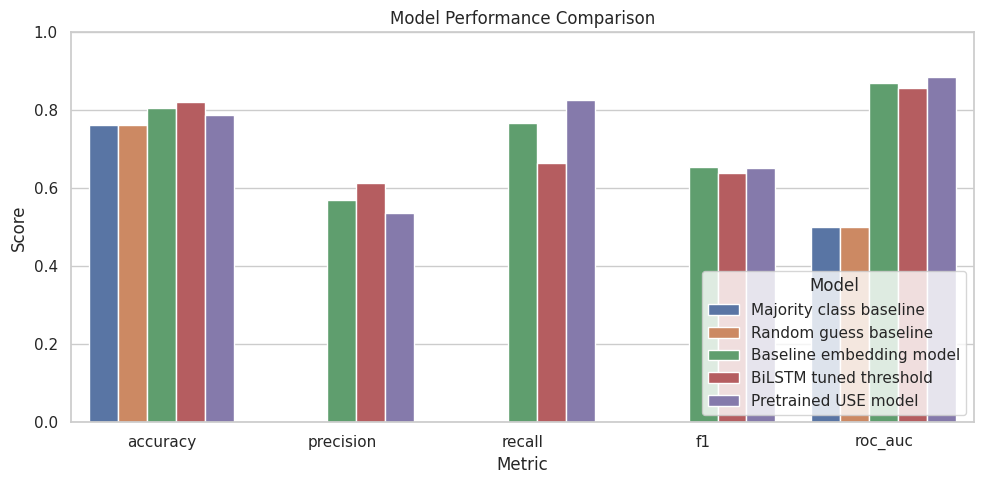

In [ ]:
comparison_long = model_comparison.melt(
    id_vars=["model", "threshold"],
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_long, x="metric", y="score", hue="model")
plt.title("Model Performance Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

## 12. Interpretation and Next Steps

The final model comparison shows that all neural-network models perform much better than the majority-class benchmark. The majority benchmark reaches about 76% accuracy only because the dataset is imbalanced toward no-clickbait posts. However, it has 0 recall and 0 F1 for the clickbait class, so it is not useful for the actual business problem.

The three neural approaches have very similar F1 scores for the clickbait class:

- Baseline embedding model: F1 = 0.6538
- BiLSTM with tuned threshold: F1 = 0.6550
- Pretrained USE model: F1 = 0.6514

The BiLSTM with a tuned threshold is the best operational choice in this notebook because it has the highest overall accuracy and the best F1 score, while also reducing false positives compared with the baseline model. This matters because a platform should not incorrectly penalize too many normal headlines. The USE model has the highest ROC-AUC and recall, so it is useful when the business goal is to catch as many clickbait posts as possible. However, its lower precision means it would send more normal posts to review.

The next step should depend on the business objective. If the platform wants a conservative moderation tool, the threshold should be increased to reduce false positives. If the platform wants a screening tool for human review, the threshold can be lower because reviewers can make the final decision. In this project, the tuned BiLSTM threshold provides a reasonable balance between precision and recall.

## 13. Limitations

This project has several limitations.

First, the model mainly uses post text. It does not fully use article content, source reputation, images, topic category, or publication context. Because of this, some misleading posts may be missed.

Second, the dataset is imbalanced. Only about one quarter of the posts are labeled as clickbait. Class weights help reduce this issue, but the model may still favor the no-clickbait class.

Third, clickbait labels can be subjective. Different people may disagree on borderline examples, so perfect model performance is not realistic.

Fourth, the dataset comes from the Webis Clickbait Corpus 2017. Online writing styles and social media platforms have changed since then, so the model may not fully generalize to newer platforms.

Finally, the neural models are harder to explain than simple rules. The notebook evaluates performance on a held-out test set, but real deployment would still require live monitoring, drift checks, and human review.

## 14. Conclusion

This project shows that neural networks can detect clickbait patterns in short online post text better than simple benchmark rules. The majority-class benchmark is not useful for the business goal because it almost never identifies clickbait. In contrast, the baseline embedding model, BiLSTM model, and pretrained USE model all identify meaningful clickbait signals.

The strongest practical result is the BiLSTM with a tuned threshold. It reaches the best overall accuracy and the best F1 score among the models tested. The performance improvement over the baseline is modest, which suggests that the simple embedding model already captures many important text signals. The USE model performs well on recall and ROC-AUC, showing that pretrained sentence embeddings are valuable for short text classification.

From a business perspective, the model should not be used as a fully automated punishment system. A better use case is decision support. The model can rank posts by clickbait risk, flag uncertain cases for human review, and help editors understand which headlines may reduce user trust. This creates value without relying too heavily on a black-box prediction.

## 15. Future Improvements

We conclude that there are several improvements that could make the project stronger.

1. **Use more features.** Future versions should include article title, article body, publisher name, topic category, image information, and media indicators. Clickbait is often a combination of text, source, and context.

2. **Test transformer-based embeddings.** A next version could use BERT-style sentence embeddings or a small transformer classifier. This may capture more nuanced language patterns than LSTM or USE embeddings.

3. **Tune more hyperparameters.** We currently explores several architectures, but a more systematic search could test vocabulary size, sequence length, embedding dimension, dropout rate, LSTM units, batch size, and learning rate.

4. **Improve threshold strategy.** Instead of using only F1, the threshold could be selected based on business cost. For example, a false positive may be costly because it unfairly penalizes a normal publisher, while a false negative may be costly because clickbait remains visible to users.

5. **Add explainability.** We could add examples of high-risk words, saliency-style analysis, or model-agnostic explanation methods. This would make the model more useful for editors and business stakeholders.

6. **Validate on newer data.** The model should be tested on newer social media posts and news headlines. This would show whether the model generalizes beyond the 2017 corpus.

7. **Create a human-in-the-loop workflow.** In a real product, the model should flag posts for review rather than automatically removing them. Human reviewers can focus on high-risk and borderline cases.

## 16. Interactive Demo

We create a function and a interactive demo to test the Generalization ability of the BiLSTM model. Type a headline or post text below to get a prediction from the model.

In [ ]:
def predict_clickbait_post(post_text, threshold=None):
    if threshold is None:
        threshold = globals().get("best_threshold", 0.50)

    text = clean_post_text([post_text])
    model_input = tf.constant([text], dtype=tf.string)
    probability = float(bilstm_model.predict(model_input, verbose=0).ravel()[0])
    prediction = "clickbait" if probability >= threshold else "no-clickbait"

    return pd.DataFrame([{
        "post_text": text,
        "clickbait_probability": round(probability, 4),
        "threshold": round(float(threshold), 4),
        "prediction": prediction,
    }])

predict_clickbait_post("You will not believe what happened to BU Questrom School Room 324 on Tuesday")

,post_text,clickbait_probability,threshold,prediction
0,You will not believe what happened to BU Questrom School Room 324 on Tuesday,0.6215,0.2198,clickbait


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

default_threshold = float(globals().get("best_threshold", 0.50))

post_text_box = widgets.Textarea(
    value="You will not believe what happened to BU Questrom School Room 324 on Tuesday",
    placeholder="Type a headline or post text here...",
    description="Post text:",
    layout=widgets.Layout(width="100%", height="120px"),
)

threshold_slider = widgets.FloatSlider(
    value=default_threshold,
    min=0.05,
    max=0.95,
    step=0.01,
    description="Threshold:",
    readout_format=".2f",
    layout=widgets.Layout(width="60%"),
)

predict_button = widgets.Button(description="Predict", button_style="primary")
demo_output = widgets.Output()

def on_predict_clicked(button):
    with demo_output:
        clear_output(wait=True)
        display(predict_clickbait_post(post_text_box.value, threshold=threshold_slider.value))

predict_button.on_click(on_predict_clicked)
display(post_text_box, threshold_slider, predict_button, demo_output)

Textarea(value='You will not believe what happened to BU Questrom School Room 324 on Tuesday', description='Po…

FloatSlider(value=0.21980367600917816, description='Threshold:', layout=Layout(width='60%'), max=0.95, min=0.0…

Button(button_style='primary', description='Predict', style=ButtonStyle())

Output()

## 17. Generative AI Use

We used Generative AI tools, including ChatGPT and Gemini 3, while working on this project. We mainly used these tools to help us understand course concepts, debug code errors, improve code comments, and revise the written explanations in the notebook and slides.

The main project decisions, including the dataset choice, train/validation/test structure, preprocessing logic, model architectures, evaluation metrics, and final interpretation, were reviewed and finalized by us. We did not use AI tools to replace the core project work.

We also checked the AI-assisted code and explanations to make sure we could understand and explain them. Any model results, figures, and conclusions reported in this notebook come from our own implementation and evaluation.